# AIRO K-Nearest Neighbors Example
## Credit Card Fraud Detection
### Created by Caden Wondell
We will compare:

1. KNN without SMOTE
2. KNN with SMOTE

## Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2: Import the Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from imblearn.over_sampling import SMOTE

## Step 3: Load the Credit Card Fraud Dataset
Load the credit card transaction data from Google Drive into a pandas DataFrame.

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/Colab_Notebooks/AIRO_CLUB/Examples/creditcard.csv"
)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 4: Look at the Dataset
View the size of the dataset and the first few transactions.

In [ ]:
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 5: Examine the Class Imbalance
Count how many normal and fraudulent transactions are in the dataset.

In [ ]:
data["Class"].value_counts()

,count
Class,
0,284315
1,492


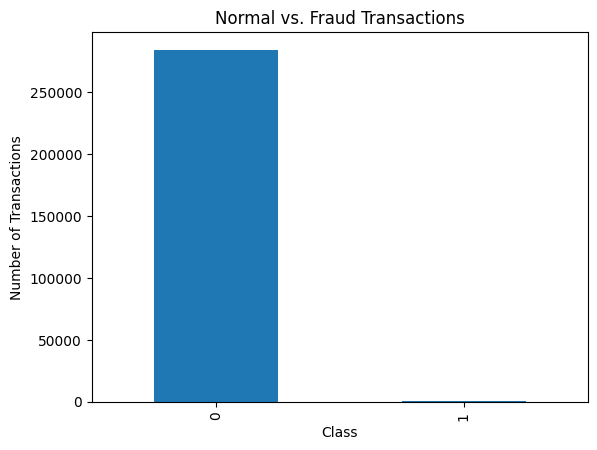

In [ ]:
data["Class"].value_counts().plot(kind="bar")

plt.title("Normal vs. Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

## Step 6: Use the Full Dataset
Use all normal and fraudulent transactions from the original dataset.

In [ ]:
data_full = data.copy()

data_full["Class"].value_counts()

,count
Class,
0,284315
1,492


## Step 7: Shuffle the Dataset
Randomly mix the normal and fraudulent transactions.

In [ ]:
data_full = data_full.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

data_full.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
1,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
2,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
3,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
4,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


## Step 8: Separate the Features and Target
Separate the information used to make predictions from the class we want to predict.

In [ ]:
X = data_full.drop("Class", axis=1) #Features

y = data_full["Class"] #Target

## Step 9: Split the Data into Training and Testing Sets
Use 80% of the data to train the model and 20% to test how well it performs on unseen transactions.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 10: Scale the Features
KNN uses distance to find nearby transactions. Scaling puts the features on comparable numerical scales.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Step 11: Find a Good Value for K

Use cross-validation to test several values of K and find the value that gives the best F1 score.

In [ ]:
knn = KNeighborsClassifier()

parameters = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15]
}

grid_search = GridSearchCV(
    knn,
    parameters,
    cv=5,
    scoring="f1"
)

grid_search.fit(
    X_train_scaled,
    y_train
)

k_results = pd.DataFrame({
    "K": grid_search.cv_results_["param_n_neighbors"],
    "F1 Score": grid_search.cv_results_["mean_test_score"]
})

k_results["F1 Score"] = k_results["F1 Score"].round(3)

print(k_results.to_string(index=False))

print()
print("Best K:", grid_search.best_params_["n_neighbors"])
print("Best F1 Score:", round(grid_search.best_score_, 3))

 K  F1 Score
 1     0.839
 3     0.851
 5     0.834
 7     0.830
 9     0.813
11     0.810
13     0.808
15     0.810

Best K: 3
Best F1 Score: 0.851


## Step 12: Create the KNN Model
Create a K-Nearest Neighbors classifier that will use the K nearest transactions to make a prediction.

In [ ]:
best_k = grid_search.best_params_["n_neighbors"]

model = KNeighborsClassifier(
    n_neighbors=best_k
)

print("KNN will use K =", best_k)

KNN will use K = 3


## Step 13: Train the KNN Model
Train the KNN model using the scaled training features and the known transaction classes.

In [ ]:
model.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=3)

## Step 14: Make Predictions
Use the trained KNN model to predict whether the transactions in the test set are normal or fraudulent.

In [ ]:
predictions = model.predict(
    X_test_scaled
)
predictions[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Step 15: View the Confusion Matrix
Compare the model's predictions with the actual transaction classes.

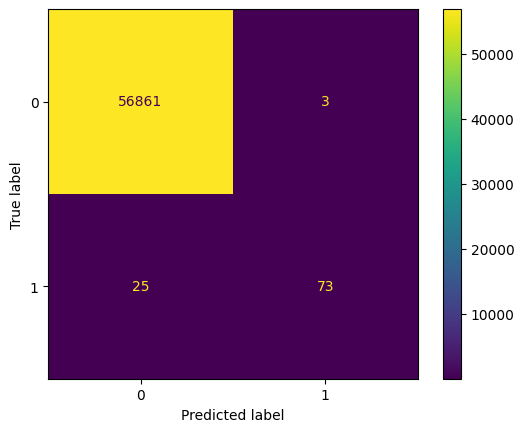

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()

## Step 16: View the Classification Metrics
View the model's precision, recall, and F1 score for normal and fraudulent transactions.

In [ ]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



#

## Step 17: Save the KNN Results

Save the fraud precision, recall, and F1 score so we can compare KNN before and after SMOTE.

In [ ]:
knn_precision = precision_score(
    y_test,
    predictions
)

knn_recall = recall_score(
    y_test,
    predictions
)

knn_f1 = f1_score(
    y_test,
    predictions
)

print("Precision:", round(knn_precision, 3))
print("Recall:", round(knn_recall, 3))
print("F1 Score:", round(knn_f1, 3))

Precision: 0.961
Recall: 0.745
F1 Score: 0.839


#SMOTE

## Step 18: Check the Training Class Balance

Look at how many normal and fraudulent transactions are in the training data before applying SMOTE.

In [ ]:
y_train.value_counts()

,count
Class,
0,227451
1,394


## Test Different SMOTE Ratios

Test several SMOTE sampling ratios and compare how each one affects fraud precision, recall, and F1 score.

The same KNN settings are used for every test so that only the amount of SMOTE changes.

In [ ]:
smote_values = [
    0.05,
    0.10,
    0.20,
    0.50,
    1.00
]

smote_results = []

for value in smote_values:

    smote = SMOTE(
        sampling_strategy=value,
        random_state=42
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_scaled,
        y_train
    )

    model_smote = KNeighborsClassifier(
        n_neighbors=best_k
    )

    model_smote.fit(
        X_train_smote,
        y_train_smote
    )

    predictions_smote = model_smote.predict(
        X_test_scaled
    )

    precision = precision_score(
        y_test,
        predictions_smote
    )

    recall = recall_score(
        y_test,
        predictions_smote
    )

    f1 = f1_score(
        y_test,
        predictions_smote
    )

    smote_results.append({
        "SMOTE Ratio": value,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

## Compare the SMOTE Ratios

Display the performance of KNN at each SMOTE sampling ratio.

In [ ]:
smote_results = pd.DataFrame(
    smote_results
)

smote_results.round(3)

,SMOTE Ratio,Precision,Recall,F1 Score
0,0.05,0.690,0.796,0.739
1,0.10,0.637,0.806,0.712
2,0.20,0.603,0.806,0.690
3,0.50,0.598,0.806,0.687
4,1.00,0.598,0.806,0.687


## Step 19: Apply SMOTE

Use SMOTE to create synthetic examples of the minority fraud class in the training data.

In [ ]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

## Step 20: Check the Class Balance After SMOTE

Check how the number of normal and fraudulent training examples changed after applying SMOTE.

In [ ]:
y_train_smote.value_counts()

,count
Class,
0,227451
1,227451


## Step 21: Create the KNN + SMOTE Model

Create another KNN classifier using the same K value as the original model.

In [ ]:
best_k = grid_search.best_params_["n_neighbors"]

model_smote = KNeighborsClassifier(
    n_neighbors=best_k
)

print("KNN will use K =", best_k)

KNN will use K = 3


## Step 22: Train the KNN + SMOTE Model

Train the KNN model using the balanced training data created by SMOTE.

In [ ]:
model_smote.fit(
    X_train_smote,
    y_train_smote
)

KNeighborsClassifier(n_neighbors=3)

## Step 23: Make Predictions with KNN + SMOTE

Use the new model to predict the same untouched test transactions used by the original KNN model.

In [ ]:
predictions_smote = model_smote.predict(
    X_test_scaled
)

## Step 24: View the KNN + SMOTE Confusion Matrix

Compare the KNN + SMOTE predictions with the actual transaction classes.

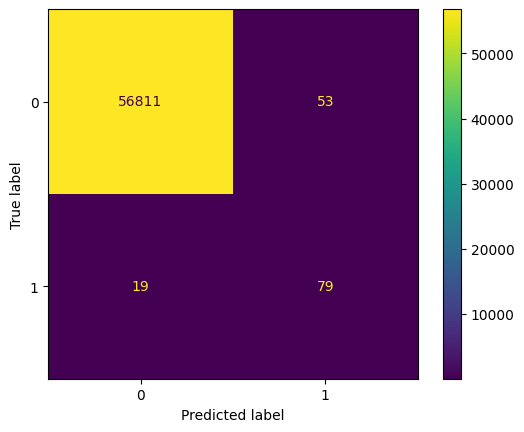

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions_smote
)

plt.show()

## Step 25: View the KNN + SMOTE Classification Metrics

View the precision, recall, and F1 score after training KNN with SMOTE-balanced data.

In [ ]:
print(
    classification_report(
        y_test,
        predictions_smote
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.81      0.69        98

    accuracy                           1.00     56962
   macro avg       0.80      0.90      0.84     56962
weighted avg       1.00      1.00      1.00     56962



## Step 26: Save the KNN + SMOTE Results

Save the fraud precision, recall, and F1 score so we can compare the two models.

In [ ]:
smote_precision = precision_score(
    y_test,
    predictions_smote
)

smote_recall = recall_score(
    y_test,
    predictions_smote
)

smote_f1 = f1_score(
    y_test,
    predictions_smote
)

## Step 27: Compare KNN vs. KNN + SMOTE

Compare how the original KNN model and the KNN + SMOTE model perform at detecting fraud.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "KNN + SMOTE"
    ],
    "Precision": [
        knn_precision,
        smote_precision
    ],
    "Recall": [
        knn_recall,
        smote_recall
    ],
    "F1 Score": [
        knn_f1,
        smote_f1
    ]
})

results

,Model,Precision,Recall,F1 Score
0,KNN,0.960526,0.744898,0.839080
1,KNN + SMOTE,0.598485,0.806122,0.686957
